# Assignment3 (GAN)

In [ ]:
name = input("Name :")
ID = input("student ID :")

Name :이서연
student ID :2412975


## Prepare

In [ ]:
import numpy as np
import time

import matplotlib.pyplot as plt
import torchvision.utils

import torch
import torch.nn as nn
import torch.optim as optim

from torch.autograd import Variable, grad
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings(action='ignore')

### Data Load with augmnetation

In [ ]:
#load dataset
dataset = 'mnist'
resolution = 32
batch_size = 64
num_workers = 1

transform = transforms.Compose([transforms.Resize(resolution),transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

if dataset == 'cifar10':
  dataset = datasets.CIFAR10(root='./data/Cifar10', train=True, download=True, transform=transform)
  data_dim = 3

elif dataset == 'mnist':
  dataset = datasets.MNIST(root='./data/MNIST', train=True, download=True, transform=transform)
  data_dim = 1

train_loader = DataLoader(dataset, batch_size = batch_size, shuffle=True, num_workers = num_workers)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 475kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


### utils

1. model weight initialization

In [ ]:
def initialize_weights(net):
	for m in net.modules():
		if isinstance(m, nn.Conv2d):
			m.weight.data.normal_(0, 0.02)
			if m.bias is not None:
				m.bias.data.zero_()
		elif isinstance(m, nn.ConvTranspose2d):
			m.weight.data.normal_(0, 0.02)
			if m.bias is not None:
				m.bias.data.zero_()
		elif isinstance(m, nn.Conv3d):
			nn.init.xavier_uniform(m.weight)
		elif isinstance(m, nn.ConvTranspose3d):
			nn.init.xavier_uniform(m.weight)
		#elif isinstance(m, nn.GRU):
		#	nn.init.xavier_uniform(m.weight)
		elif isinstance(m, nn.Linear):
			m.weight.data.normal_(0, 0.02)
			m.bias.data.zero_()

2. for image

In [ ]:
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

def show_image(img): # image visualization (input = image)
    plt.ion()
    img = to_img(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def show_images(Generator, fixed_z): # generated image visualization (input = model(G) and latent vector)
    Generator.eval()
    with torch.no_grad():
        # sample latent vectors from the standard normal distribution
        fake_image_batch = Generator(fixed_z)
        fake_image_batch = fake_image_batch.cpu()

        fig, ax = plt.subplots(figsize=(8, 8))
        show_image(torchvision.utils.make_grid(fake_image_batch.data[:100],10,5))
        plt.show()
    Generator.train(True)

## Model

### Generator

In [ ]:
class Gen(nn.Module):
	def __init__(self, output_dim):
		super(Gen, self).__init__()
		self.input_dim = 100 #원하는 채널 수로 변경해도 됩니다!
		self.output_dim = output_dim

		self.deconv = nn.Sequential(
			# 1 -> 4
			nn.Conv2d(self.input_dim, 256, 4, 1, 3, bias=False),
			nn.BatchNorm2d(256),
			nn.ReLU(),
			nn.Upsample(scale_factor=2, mode='nearest'),

			# 4 -> 8
			##과제##
			## - 해당 부분을 채우세요 - ##
			nn.Conv2d(256, 128, 3, 1, 1, bias=False),
			nn.BatchNorm2d(128),
			nn.ReLU(),
			nn.Upsample(scale_factor=2, mode='nearest'),
			##Convolution layer -> Normalization -> Activation function -> Upsample 순서로 채우세요 #
			## - 해당 부분을 채우세요 - ##
			##과제##

			# 8 -> 16
			##과제##
			## - 해당 부분을 채우세요 - ##
			nn.Conv2d(128, 64, 3, 1, 1, bias=False),
			nn.BatchNorm2d(64),
			nn.ReLU(),
			nn.Upsample(scale_factor=2, mode='nearest'),
			##Convolution layer -> Normalization -> Activation function -> Upsample 순서로 채우세요 #
			## - 해당 부분을 채우세요 - ##
			##과제##

			#16 -> 32
			nn.Conv2d(64, self.output_dim, 3, 1, 1, bias=False),
			nn.Tanh(),
		)

		initialize_weights(self)

	def forward(self, z):
		x = z.view(-1, self.input_dim, 1, 1)
		x = self.deconv(x)
		return x

## Discriminator

In [ ]:
class Dis(nn.Module):
	def __init__(self, input_dim):
		super(Dis, self).__init__()
		self.input_dim = input_dim
		self.output_dim  = 1 # Real or Fake

		self.conv = nn.Sequential(
			# 32 ->16
			##과제##
			## - 해당 부분을 채우세요 - ##
			nn.Conv2d(self.input_dim, 64, 3, 2, 1, bias=False),
			nn.BatchNorm2d(64),
			nn.LeakyReLU(0.2),
			##Convolution layer -> Normalization -> Activation function  순서로 채우세요 #
			## - 해당 부분을 채우세요 - ##
			##과제##
		)

		self.fc = nn.Sequential(
			##과제##
			## - 해당 부분을 채우세요 - ##
			nn.Linear(64*16*16, 512),
			nn.BatchNorm1d(512),
			nn.LeakyReLU(0.2),
			##Linear layer -> Normalization -> Activation function  순서로 채우세요 #
			## - 해당 부분을 채우세요 - ##
			##과제##

			##과제##
			## - 해당 부분을 채우세요 - ##
			nn.Linear(512, 256),
			nn.BatchNorm1d(256),
			nn.LeakyReLU(0.2),
			##Linear layer -> Normalization -> Activation function  순서로 채우세요 #
			## - 해당 부분을 채우세요 - ##
			##과제##

			nn.Linear(256, self.output_dim),
			nn.Sigmoid(),
		)

		initialize_weights(self)

	def forward(self, input):
		x = self.conv(input)
		x = self.fc(x.view(-1,64*16*16))
		return x

## Adversarial Training

Hyperparameter

In [ ]:
total_epoch = 10

beta1 = 0.5
beta2 = 0.999
lrG = 0.00005 #0.0002
lrD = 0.00005 #0.0002


Model & Optimizer & Loss

In [ ]:
#construct model G & D
Generator = Gen(data_dim)
Discriminator = Dis(data_dim)

#define optimizer for G & D
G_optimizer = optim.Adam(Generator.parameters(), lr=lrG, betas=(beta1, beta2))
D_optimizer = optim.Adam(Discriminator.parameters(), lr=lrD, betas=(beta1, beta2))


Generator = Generator.cuda()
Discriminator = Discriminator.cuda()
BCE_loss = nn.BCELoss().cuda() #BCELoss : Binary Cross Entropy Loss

Training

Dataset Length  60000
[E000]  G_loss :  0.699316   D_loss :  1.399176 = 0.666877 + 0.732299
[E000]  G_loss :  0.699205   D_loss :  1.330091 = 0.667238 + 0.662853
[E000]  G_loss :  0.713177   D_loss :  1.288532 = 0.644131 + 0.644401
[E000]  G_loss :  0.696046   D_loss :  1.277642 = 0.656673 + 0.620969
[E000]  G_loss :  0.702055   D_loss :  1.295748 = 0.653174 + 0.642574
[E000]  G_loss :  0.708143   D_loss :  1.277021 = 0.641915 + 0.635106
[E000]  G_loss :  0.703357   D_loss :  1.292559 = 0.656512 + 0.636047
[E000]  G_loss :  0.699417   D_loss :  1.261333 = 0.649641 + 0.611693
[E000]  G_loss :  0.708169   D_loss :  1.256314 = 0.639086 + 0.617228
[E000]  G_loss :  0.731685   D_loss :  1.272864 = 0.630964 + 0.641900


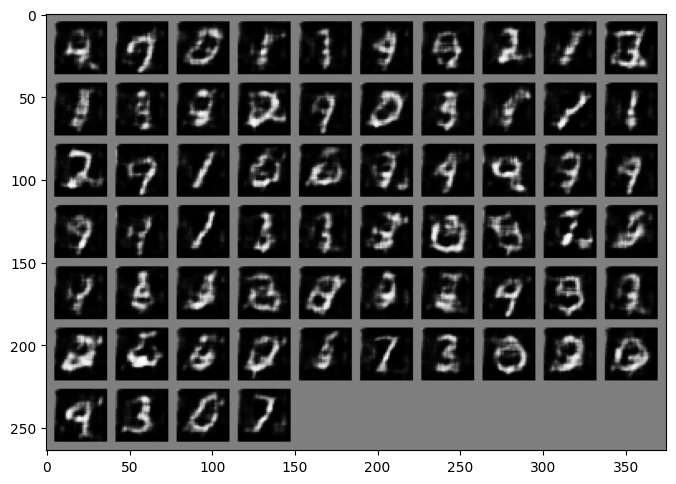

[E001]  G_loss :  0.726080   D_loss :  1.262011 = 0.636156 + 0.625855
[E001]  G_loss :  0.728442   D_loss :  1.287934 = 0.638222 + 0.649713
[E001]  G_loss :  0.708057   D_loss :  1.294402 = 0.652705 + 0.641697
[E001]  G_loss :  0.698048   D_loss :  1.240545 = 0.636255 + 0.604290
[E001]  G_loss :  0.716636   D_loss :  1.283064 = 0.636767 + 0.646298
[E001]  G_loss :  0.717326   D_loss :  1.273018 = 0.634967 + 0.638051
[E001]  G_loss :  0.725748   D_loss :  1.254488 = 0.622997 + 0.631491
[E001]  G_loss :  0.746297   D_loss :  1.247010 = 0.609474 + 0.637536
[E001]  G_loss :  0.710353   D_loss :  1.209142 = 0.616055 + 0.593087
[E001]  G_loss :  0.737316   D_loss :  1.207295 = 0.599375 + 0.607920


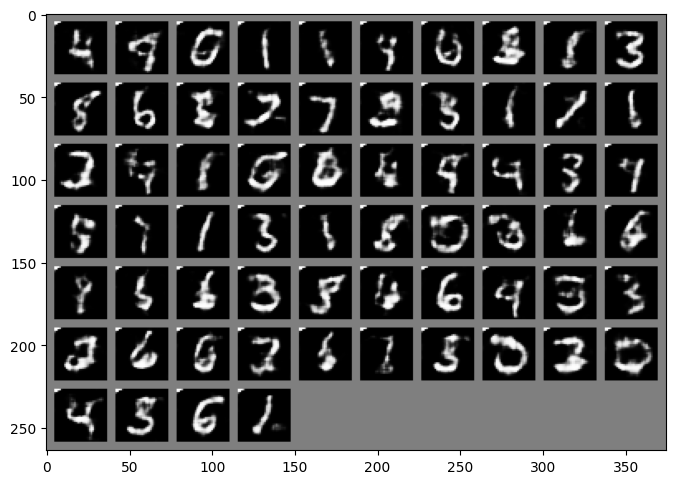

[E002]  G_loss :  0.709561   D_loss :  1.218369 = 0.611155 + 0.607214
[E002]  G_loss :  0.731173   D_loss :  1.206221 = 0.606077 + 0.600144
[E002]  G_loss :  0.697327   D_loss :  1.207445 = 0.627425 + 0.580020
[E002]  G_loss :  0.719428   D_loss :  1.264803 = 0.634573 + 0.630230
[E002]  G_loss :  0.705637   D_loss :  1.229504 = 0.627080 + 0.602424
[E002]  G_loss :  0.748116   D_loss :  1.189984 = 0.586351 + 0.603634
[E002]  G_loss :  0.728310   D_loss :  1.201797 = 0.626786 + 0.575011
[E002]  G_loss :  0.729747   D_loss :  1.241384 = 0.611864 + 0.629520
[E002]  G_loss :  0.731210   D_loss :  1.161424 = 0.593141 + 0.568282
[E002]  G_loss :  0.709910   D_loss :  1.182922 = 0.609608 + 0.573314


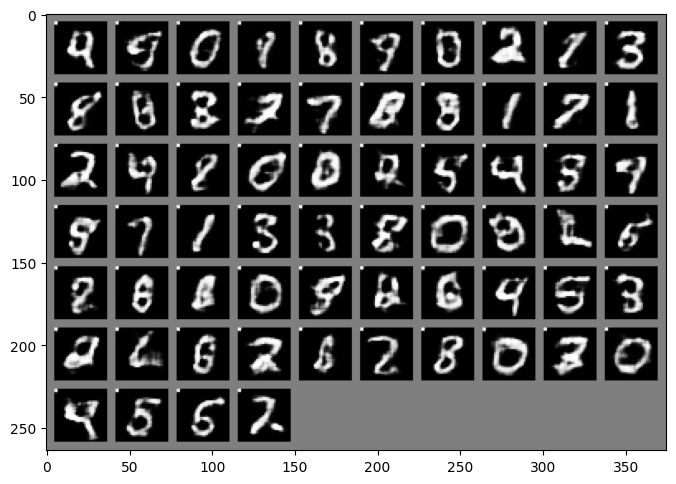

[E003]  G_loss :  0.725911   D_loss :  1.199688 = 0.613159 + 0.586528
[E003]  G_loss :  0.765747   D_loss :  1.209697 = 0.575092 + 0.634604
[E003]  G_loss :  0.712846   D_loss :  1.186348 = 0.603337 + 0.583011
[E003]  G_loss :  0.730350   D_loss :  1.210752 = 0.613820 + 0.596932
[E003]  G_loss :  0.761748   D_loss :  1.210891 = 0.587085 + 0.623806
[E003]  G_loss :  0.755935   D_loss :  1.164939 = 0.567808 + 0.597131
[E003]  G_loss :  0.695992   D_loss :  1.275223 = 0.630459 + 0.644764
[E003]  G_loss :  0.779196   D_loss :  1.166842 = 0.553898 + 0.612944
[E003]  G_loss :  0.727476   D_loss :  1.156528 = 0.582474 + 0.574053
[E003]  G_loss :  0.740911   D_loss :  1.161696 = 0.599432 + 0.562264


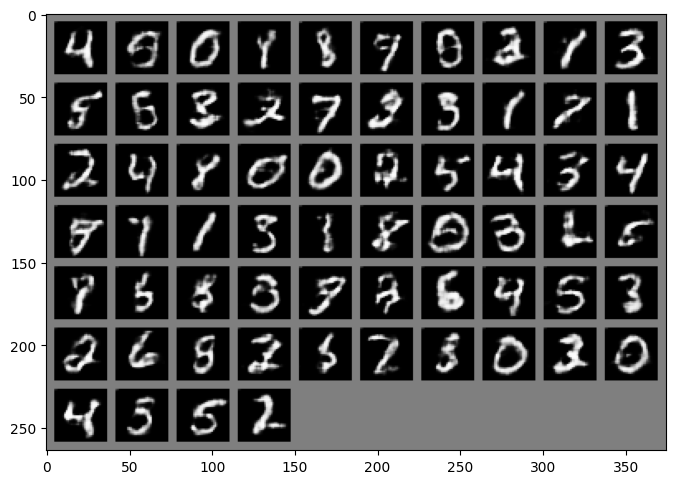

[E004]  G_loss :  0.717657   D_loss :  1.210684 = 0.623898 + 0.586786
[E004]  G_loss :  0.716609   D_loss :  1.127892 = 0.589416 + 0.538476
[E004]  G_loss :  0.729884   D_loss :  1.123828 = 0.566604 + 0.557223
[E004]  G_loss :  0.689804   D_loss :  1.134007 = 0.580047 + 0.553960
[E004]  G_loss :  0.761172   D_loss :  1.085555 = 0.533138 + 0.552417
[E004]  G_loss :  0.705280   D_loss :  1.133917 = 0.571503 + 0.562413
[E004]  G_loss :  0.753240   D_loss :  1.186935 = 0.575759 + 0.611176
[E004]  G_loss :  0.708258   D_loss :  1.184403 = 0.606558 + 0.577845
[E004]  G_loss :  0.735386   D_loss :  1.102549 = 0.556311 + 0.546238
[E004]  G_loss :  0.754517   D_loss :  1.141420 = 0.561460 + 0.579960


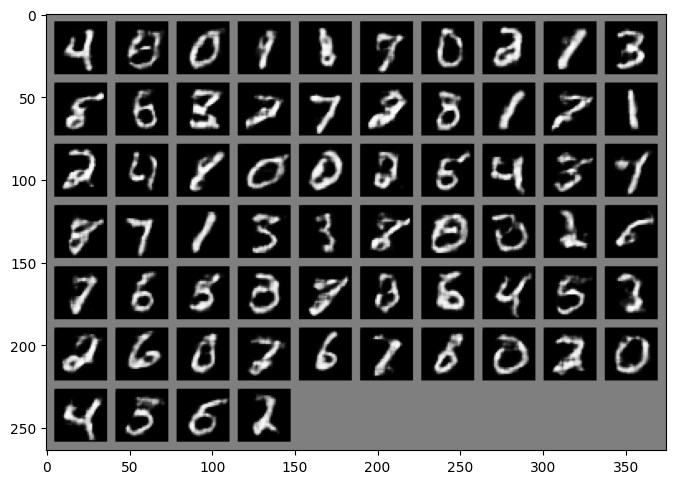

[E005]  G_loss :  0.701057   D_loss :  1.111961 = 0.576196 + 0.535766
[E005]  G_loss :  0.749458   D_loss :  1.090403 = 0.534882 + 0.555521
[E005]  G_loss :  0.746821   D_loss :  1.163839 = 0.599380 + 0.564459
[E005]  G_loss :  0.737893   D_loss :  1.150619 = 0.553950 + 0.596669
[E005]  G_loss :  0.757269   D_loss :  1.184865 = 0.602898 + 0.581966
[E005]  G_loss :  0.671157   D_loss :  1.101532 = 0.593756 + 0.507776
[E005]  G_loss :  0.740928   D_loss :  1.217557 = 0.600264 + 0.617293
[E005]  G_loss :  0.678244   D_loss :  1.108069 = 0.579809 + 0.528260
[E005]  G_loss :  0.753648   D_loss :  1.102105 = 0.532942 + 0.569163
[E005]  G_loss :  0.679289   D_loss :  1.152216 = 0.594585 + 0.557631


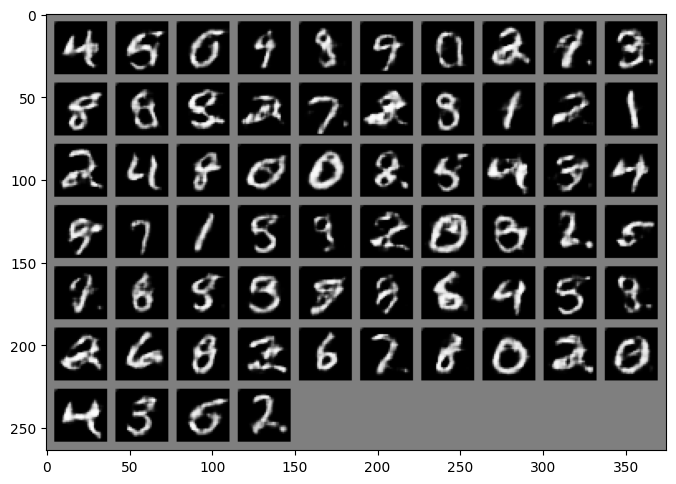

[E006]  G_loss :  0.726714   D_loss :  1.098544 = 0.560194 + 0.538349
[E006]  G_loss :  0.742179   D_loss :  1.180254 = 0.576809 + 0.603445
[E006]  G_loss :  0.803405   D_loss :  1.152241 = 0.528388 + 0.623853
[E006]  G_loss :  0.821952   D_loss :  1.135566 = 0.516245 + 0.619321
[E006]  G_loss :  0.718549   D_loss :  1.107136 = 0.560873 + 0.546263
[E006]  G_loss :  0.822696   D_loss :  1.078582 = 0.530252 + 0.548330
[E006]  G_loss :  0.759616   D_loss :  1.116995 = 0.543705 + 0.573290
[E006]  G_loss :  0.788493   D_loss :  1.074066 = 0.525854 + 0.548212
[E006]  G_loss :  0.709533   D_loss :  1.089542 = 0.557313 + 0.532229
[E006]  G_loss :  0.780268   D_loss :  1.153452 = 0.524811 + 0.628640


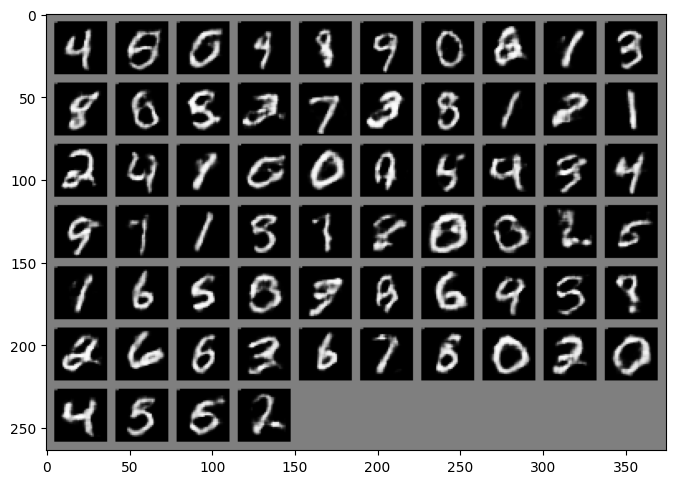

[E007]  G_loss :  0.756397   D_loss :  1.027765 = 0.509542 + 0.518222
[E007]  G_loss :  0.672332   D_loss :  1.093113 = 0.603264 + 0.489849
[E007]  G_loss :  0.818771   D_loss :  1.056076 = 0.483185 + 0.572891
[E007]  G_loss :  0.813792   D_loss :  1.086472 = 0.544967 + 0.541506
[E007]  G_loss :  0.750321   D_loss :  1.142964 = 0.541138 + 0.601826
[E007]  G_loss :  0.735544   D_loss :  1.063591 = 0.528753 + 0.534837
[E007]  G_loss :  0.731749   D_loss :  1.136894 = 0.592785 + 0.544109
[E007]  G_loss :  0.704981   D_loss :  1.093342 = 0.558149 + 0.535193
[E007]  G_loss :  0.703735   D_loss :  1.066377 = 0.540338 + 0.526039
[E007]  G_loss :  0.728252   D_loss :  1.059145 = 0.527395 + 0.531750


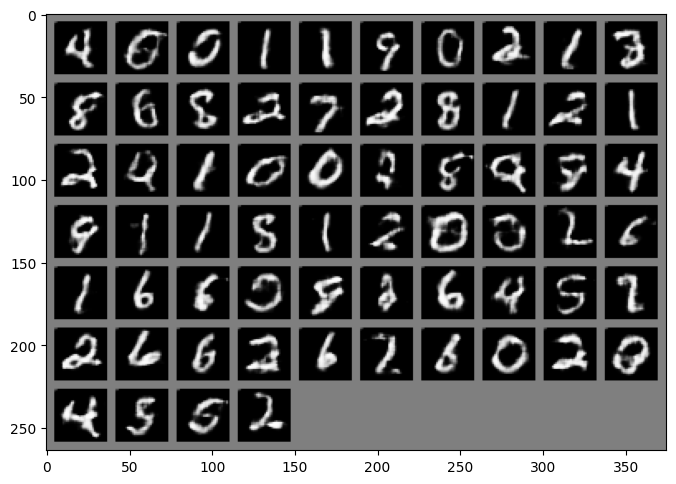

[E008]  G_loss :  0.700256   D_loss :  1.134673 = 0.573784 + 0.560889
[E008]  G_loss :  0.771802   D_loss :  1.125400 = 0.566309 + 0.559091
[E008]  G_loss :  0.748440   D_loss :  1.035018 = 0.558193 + 0.476824
[E008]  G_loss :  0.725357   D_loss :  1.001073 = 0.557020 + 0.444053
[E008]  G_loss :  0.719248   D_loss :  1.116347 = 0.564788 + 0.551559
[E008]  G_loss :  0.770452   D_loss :  1.090121 = 0.528053 + 0.562068
[E008]  G_loss :  0.798234   D_loss :  1.086204 = 0.501255 + 0.584950
[E008]  G_loss :  0.750579   D_loss :  1.147119 = 0.585062 + 0.562056
[E008]  G_loss :  0.745542   D_loss :  1.107117 = 0.578310 + 0.528807
[E008]  G_loss :  0.719031   D_loss :  1.034772 = 0.552363 + 0.482409


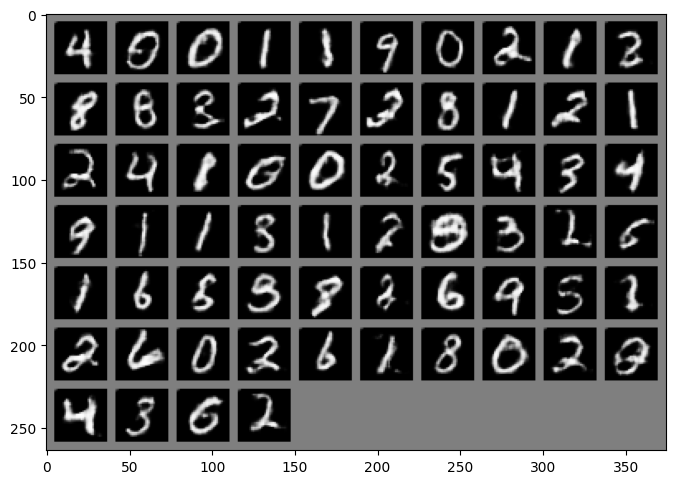

[E009]  G_loss :  0.740425   D_loss :  1.075767 = 0.526419 + 0.549348
[E009]  G_loss :  0.809069   D_loss :  1.053599 = 0.515425 + 0.538174
[E009]  G_loss :  0.827850   D_loss :  0.993494 = 0.512456 + 0.481038
[E009]  G_loss :  0.759677   D_loss :  1.042773 = 0.516719 + 0.526054
[E009]  G_loss :  0.788542   D_loss :  1.009549 = 0.497351 + 0.512198
[E009]  G_loss :  0.766443   D_loss :  1.152717 = 0.551772 + 0.600944
[E009]  G_loss :  0.784812   D_loss :  1.104640 = 0.528263 + 0.576378
[E009]  G_loss :  0.734636   D_loss :  1.118529 = 0.592463 + 0.526065
[E009]  G_loss :  0.721289   D_loss :  1.037563 = 0.530269 + 0.507294
[E009]  G_loss :  0.786463   D_loss :  0.997427 = 0.486328 + 0.511099


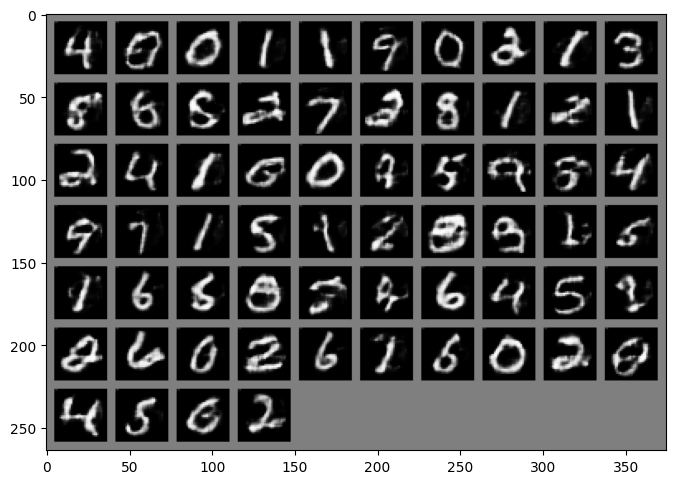

In [ ]:

y_real_, y_fake_ = Variable(torch.ones(batch_size, 1).cuda()), Variable(torch.zeros(batch_size, 1).cuda())
fixed_z = Variable(torch.rand(batch_size, 100).cuda())


#train start!
Discriminator.train()
start_time = time.time()

print("Dataset Length ", train_loader.dataset.__len__())

for epoch in range(total_epoch):
  Generator.train()
  epoch_start_time = time.time()

  for iB, (img_,_) in enumerate(train_loader):
    if iB == train_loader.dataset.__len__() // batch_size:
      break

    #Latent space
    ## z_ -> ( batch_size x 100 ) uniform distribution / randn_ : normal gaussian distribution
    z_ = torch.rand(batch_size, 100)

    z_, img_ = Variable(z_.cuda()), Variable(img_.cuda())


    #----Update D_network----#
    D_optimizer.zero_grad()

    D_real = Discriminator(img_)
    D_real_loss = BCE_loss(D_real, y_real_)

    fake_img_ = Generator(z_)
    D_fake = Discriminator(fake_img_)
    D_fake_loss = BCE_loss(D_fake, y_fake_)

    D_loss = D_fake_loss + D_real_loss
    D_loss.backward()

    # ***only for train very well***#
    num_real_correct = torch.sum(D_real > 0.5)
    num_fake_correct = torch.sum(D_fake < 0.5)
    D_acc = float(num_real_correct.item() + num_fake_correct.item()) / (batch_size*2)
    if D_acc < 0.8:
      D_optimizer.step()
    # ***only for train very well***#


    #----Update G_network----#
    for itr in range(3):
      G_optimizer.zero_grad()
      G_ = Generator(z_)

      D_fake = Discriminator(G_)
      G_loss = BCE_loss(D_fake, y_real_)

      G_loss.backward()
      G_optimizer.step()

    #---check train result ----#
    if(iB % 100 == 0) and (epoch%1==0):
      print('[E%03d]'%(epoch)+'  G_loss :  %.6f '%(G_loss.item())+'  D_loss :  %.6f = %.6f + %.6f'%(D_loss.item(), D_fake_loss.item(), D_real_loss.item()))

  show_images(Generator, fixed_z)
  Generator.train()
